In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:

# === Parámetros iniciales (modificables) ===

CL_medio_total = 0.9281
alpha_medio_total = 4.11
a = CL_medio_total/alpha_medio_total             #Pendiente de la curva de sustentación del perfil cl = a*alpha

p = 1013.25 #hPa            #Presion del aire

c = 0.2           #Cuerda
k_beta = 1.5     #Rigidez
rR = 4           #Radio del rotor
e = 0          #Excentricida 
mp = 12.8/10   #Masa de una pala por unidad de longitud
Mp = mp * (rR - e)  #Masa de una pala

x_GB = (rR - e) / 2
omega = 34
I_beta = (1/3) * mp * (rR - e)**3
gamma = p * a * c * rR**4 / I_beta

Vx = 35
mu_xA = -Vx / (omega * rR)

lambda_beta = np.sqrt(1 + (x_GB * Mp * e) / I_beta + k_beta / (I_beta * omega**2))
theta = 2.5*(np.pi/180) #Angulo de paso de un elemento de pala
Vz = 0 
mu_zA = -Vz / (omega * rR)
lmbda_i = 0 
lmbda = lmbda_i + mu_zA


In [3]:

# === Funciones auxiliares ===
def P(psi):
    return (gamma / 8) * (1 + (4/3) * mu_xA * np.sin(psi))

def Q(psi):
    return lambda_beta**2 + (gamma / 8) * ( (4/3) * mu_xA * np.cos(psi) + 2 * mu_xA**2 * np.cos(psi) * np.sin(psi) )

def R(psi):
    term_theta = (gamma / 8) * ( 1 + (8/3) * mu_xA * np.sin(psi) + 2 * mu_xA**2 * np.sin(psi)**2 ) * theta
    term_lambda = (gamma / 8) * ((4/3) + 2 * mu_xA * np.sin(psi)) * lmbda
    return term_theta + term_lambda



In [4]:

# === Sistema de ecuaciones de primer orden ===
def system(psi, y):
    y0, y1 = y
    return [y1, -P(psi) * y1 - Q(psi) * y0 + R(psi)]


In [9]:

# === Intervalo de psi y condiciones iniciales ===
psi_start = 0
psi_end = 185*(np.pi/180)
psi_span = (psi_start, psi_end)
y0 = [0.0, 0.0]  # beta(0) = 0, beta'(0) = 0


In [10]:

# === Resolver la EDO ===
sol = solve_ivp(system, psi_span, y0, 'LSODA', dense_output=True)
psi_vals = np.arange(psi_start, psi_end, 5*(np.pi/180))
beta_vals = sol.sol(psi_vals)[0]

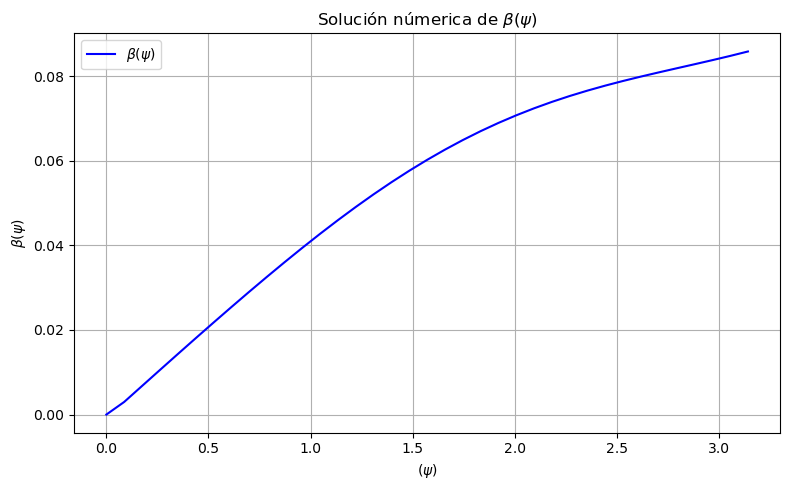

In [13]:

# === Graficar la solución ===
plt.figure(figsize=(8, 5))
plt.plot(psi_vals, beta_vals, label=r'$\beta(\psi)$', color='blue')
plt.title(r'Solución númerica de $\beta(\psi)$')
plt.xlabel(r'$(\psi)$')
plt.ylabel(r'$\beta(\psi)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
